<a href="https://colab.research.google.com/github/Sshahsavar/credit-risk-modeling/blob/main/Part_3_End_to_End_Credit_Risk_Modeling_(PD_%26_Portfolio_Optimization).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3: PD Scorecard and Credit Decisions
*Credit risk project on Lending Club loans: Part 3 of 5*

## Project map

| Part | Topic | Main question | Main output |
|---|---|---|---|
| 0 | Data Foundation | What data do we need, and how do we prepare it? | Clean loan table and macro data |
| 1 | Loss Given Default (LGD) | How much do we lose when a borrower defaults? | LGD by grade and downturn LGD |
| 2 | PD Algorithm Benchmark | Which model predicts default best? | Choice of PD model |
| **3** | **PD Scorecard and Credit Decisions (this part)** | **How do we build, check and use a PD model?** | **Calibrated PD, score, cut-off, stability check** |
| 4 | Macroeconomic Stress Testing | How much would the portfolio lose in a recession? | 9-quarter loss by scenario |
| 5 | Forward Flow and Securitization | Did the purchased loans perform as expected, and who carries the loss? | Monitoring, waterfall, tranche break-even |

The whole project is built around the expected loss formula, $EL = PD \times LGD \times EAD$. Part 1 measures LGD, Parts 2 and 3 measure PD, and Parts 4 and 5 add EAD, the economy and the investor view.

## What this part does

Part 2 chose the methods. Part 3 builds the full PD model and follows the steps a bank takes before it uses a model:
1. build the model;
2. check that it ranks borrowers well;
3. check that its probabilities are correct (calibration);
4. turn it into a credit score;
5. check that the population is stable over time;
6. explain the model's decisions;
7. use it to set the approval cut-off that maximizes profit.

## How it connects to the other parts

* **Uses:** the loan table from Part 0 and the LGD from Part 1 (`lgd_satellite.json`), which gives the loss on each defaulted loan in the profit analysis.
* **Builds on Part 2:** the WOE logistic scorecard is the **champion** (easy to explain), and LightGBM is the **challenger** (best accuracy).
* **Feeds:** the calibration and stability findings explain why the default rate of new loans can move away from the model, a theme that returns in Part 4 (stress testing) and Part 5 (monitoring actual vs. expected losses).

## Why it matters for credit risk

A PD model is used every day to approve loans, set prices, and calculate provisions and capital. For these uses, ranking borrowers well (AUC) is not enough. The probabilities must also be correct, the model must stay stable, and every decision must be explainable. This notebook shows each of these checks.

## Methodology

| Step | What we do | Method |
|---|---|---|
| 2 | Sample, target, variables | 36-month loans 2010–2015, WOE binning and Information Value |
| 3 | Champion vs. challenger | WOE logistic regression vs. LightGBM; AUC, Gini, KS |
| 4 | Calibration and score | predicted vs. actual default rate, Brier score, points-to-double-the-odds scaling |
| 5 | Stability | Population Stability Index (PSI), Characteristic Stability Index (CSI) |
| 6 | Explainability | SHAP values |
| 7 | Credit decision | profit by cut-off using real cash flows, break-even PD |

## Main results

* **Ranking:** on the 2015 test loans, LightGBM reaches AUC 0.672 and KS 25.0; the 9-variable scorecard reaches AUC 0.649 and KS 21.3. All scorecard signs are correct, and the default rate falls steadily with the score, from 29.4% in the lowest band to 2.6% at 580–600 points.
* **Calibration:** both models predict about 10% too few defaults for 2015 (13.1% and 13.5% vs. 14.9% actual).
* **Stability:** the score distribution did not change at all (PSI = 0.0002). The same kind of borrower simply defaulted more often in 2015. This is called **concept drift**, and the right fix is to recalibrate the model, not to rebuild it.
* **Explainability:** SHAP confirms sensible drivers: FICO, income, recent credit inquiries, loan-to-income and DTI.
* **Credit decision:** with real interest income and a 91% LGD, a loan is profitable in expectation up to a PD of 26.8%. Lending Club had already screened and priced its loans, so almost every approved loan is below this level. The best LightGBM cut-off rejects only 1% of loans and adds \$1.5M (+0.7%) to a \$228M profit.

Tech stack: Python, pandas, scikit-learn, LightGBM, scorecardpy, SHAP, SciPy, Matplotlib, Google Colab.

# Step 1: Setup and Data Loading

**Why this step?** We need the clean loan table (Part 0) for the model, and the LGD by grade (Part 1) for the profit analysis in Step 7.

**How we do it.** We mount Google Drive, read the folder path from the Colab secret `credit_ris_DIR`, and load both files. scorecardpy and SHAP are installed if needed.

In [1]:
try:
    import scorecardpy as sc
except ImportError:
    !pip install scorecardpy
    import scorecardpy as sc
try:
    import shap
except ImportError:
    !pip install shap
    import shap
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from IPython.display import display
warnings.filterwarnings('ignore')

# 1.1. Mount Google Drive and define the project folder
from google.colab import drive
drive.mount('/content/drive')
import google.colab.userdata
PROJECT_DIR = google.colab.userdata.get('credit_ris_DIR')
# 1.2. Load the Part 0 and Part 1 outputs
lc = pd.read_pickle(os.path.join(PROJECT_DIR, 'lc_clean.pkl'))
with open(os.path.join(PROJECT_DIR, 'lgd_satellite.json')) as f:
    lgd_sat = json.load(f)
print(f"Loans loaded: {len(lc):,}")
print(f"Long-run average LGD from Part 1: {lgd_sat['lra_default_weighted']:.2%}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60724 sha256=4013f468b261be1970e1887293ac16f4004ebb2537ffb5c98a8afdeaa8708376
  Stored in directory: /root/.cache/pip/wheels/d7/a8/fb/593dcef7717ee8a731e22872353b598d8d8bef4ee405a1c54a
Successfully built scorecardpy


/usr/local/lib/python3.13/dist-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Mounted at /content/drive
Loans loaded: 2,260,668
Long-run average LGD from Part 1: 91.19%


# Step 2: Sample, Target and Variables

**Why this step?** A PD model is only as good as its sample and its variables. We need loans with a known outcome, variables that were known when the loan was approved, and a way to measure how useful each variable is.

**How we do it.**
* **Sample:** 36-month loans issued 2010–2015 that were repaid or charged off. All of them ended before the snapshot date, so the outcome is known. `TARGET = 1` means charged off.
* **Variables:** only information available at application. We exclude Lending Club's grade, sub-grade and interest rate, because they are the lender's own risk rating; with them, our model would just copy Lending Club's model. We exclude the borrower's state, because location can be a proxy for protected characteristics.
* **Two affordability ratios:** **loan-to-income** (how big is the loan compared with income?) and **revolving-debt-to-income** (how heavy is the existing card debt?).
* **Out-of-time split:** training = 2010–2014, test = 2015.
* **WOE binning and Information Value (IV)**, learned on the training set only. We keep the variables with IV ≥ 0.02 for the scorecard.

In [2]:
print("--- Building the Modeling Sample ---")

# 1. 36-month loans issued 2010-2015 with a completed outcome
df = lc[(lc['term_m'] == 36) & lc['issue_year'].between(2010, 2015) & lc['outcome'].isin(['default', 'paid'])].copy()
df['TARGET'] = (df['outcome'] == 'default').astype(int)

# 2. Domain-specific affordability ratios
income = df['annual_inc'].where(df['annual_inc'] > 0)
df['log_annual_inc'] = np.log1p(df['annual_inc'].clip(lower=0))
df['LOAN_TO_INCOME'] = df['loan_amnt'] / income             # How large is the loan relative to earnings?
df['REVOL_DEBT_TO_INCOME'] = df['revol_bal'] / income       # How heavy is the existing revolving debt?

FEATURES = ['fico', 'dti', 'log_annual_inc', 'LOAN_TO_INCOME', 'REVOL_DEBT_TO_INCOME', 'revol_util', 'loan_amnt',
            'emp_years', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'mort_acc',
            'home_ownership', 'verification_status', 'purpose']

# 3. Out-of-time split
train = df[df['issue_year'] <= 2014].reset_index(drop=True)
test = df[df['issue_year'] == 2015].reset_index(drop=True)
y_train, y_test = train['TARGET'].values, test['TARGET'].values
print(f"Train (2010-2014): {len(train):,} loans | default rate {y_train.mean():.2%}")
print(f"Test  (2015):      {len(test):,} loans | default rate {y_test.mean():.2%}")

# 4. WOE binning and Information Value (fitted on the training set only)
print("\nCalculating Information Value (IV) and WOE bins on the training set...")
bins = sc.woebin(train[FEATURES + ['TARGET']], y='TARGET')
iv_df = pd.DataFrame({'Information Value (IV)': {k: v['total_iv'].iloc[0] for k, v in bins.items()}})
iv_df = iv_df.sort_values('Information Value (IV)', ascending=False)

print("\n--- Feature Information Value (IV) ---")
print("Rule of Thumb: < 0.02 (Useless), 0.02-0.1 (Weak), 0.1-0.3 (Medium), > 0.3 (Strong)")
display(iv_df.round(4))

strongest_feature = iv_df.index[0]
print(f"\n--- WOE Binning Details for: {strongest_feature} ---")
display(bins[strongest_feature][['bin', 'count_distr', 'badprob', 'woe', 'total_iv']])

# 5. Keep features with at least weak predictive power (IV >= 0.02) for the scorecard
SCORECARD_FEATURES = iv_df[iv_df['Information Value (IV)'] >= 0.02].index.tolist()
print(f"\nScorecard features (IV >= 0.02): {SCORECARD_FEATURES}")

--- Building the Modeling Sample ---
Train (2010-2014): 329,719 loans | default rate 13.07%
Test  (2015):      283,026 loans | default rate 14.89%

Calculating Information Value (IV) and WOE bins on the training set...
[INFO] creating woe binning ...
Binning on 329719 rows and 18 columns in 00:00:54

--- Feature Information Value (IV) ---
Rule of Thumb: < 0.02 (Useless), 0.02-0.1 (Weak), 0.1-0.3 (Medium), > 0.3 (Strong)


,Information Value (IV)
fico,0.1373
log_annual_inc,0.0821
dti,0.0461
mort_acc,0.0435
LOAN_TO_INCOME,0.0417
home_ownership,0.0371
inq_last_6mths,0.0300
revol_util,0.0248
purpose,0.0217
emp_years,0.0174



--- WOE Binning Details for: fico ---


,bin,count_distr,badprob,woe,total_iv
0,"[-inf,685.0)",0.413197,0.169063,0.302483,0.137265
1,"[685.0,710.0)",0.305117,0.128137,-0.022765,0.137265
2,"[710.0,740.0)",0.177117,0.090293,-0.415303,0.137265
3,"[740.0,760.0)",0.050219,0.065104,-0.769677,0.137265
4,"[760.0,inf)",0.054349,0.045759,-1.142765,0.137265



Scorecard features (IV >= 0.02): ['fico', 'log_annual_inc', 'dti', 'mort_acc', 'LOAN_TO_INCOME', 'home_ownership', 'inq_last_6mths', 'revol_util', 'purpose']


### Results

1. **Sample:** 329,719 training loans (default rate 13.07%) and 283,026 test loans (14.89%). The 2015 loans are riskier, which is exactly the kind of change an out-of-time test is meant to reveal.
2. **Variable strength:** FICO is the only medium-strength variable (IV = 0.137). It is followed by income (0.082), DTI (0.046), number of mortgage accounts (0.044), loan-to-income (0.042), home ownership (0.037), recent credit inquiries (0.030), revolving utilization (0.025) and loan purpose (0.022). These **9 variables** enter the scorecard. Eight variables with IV below 0.02 are dropped.
3. **FICO shows a clean, steady pattern.** The default rate falls from 16.9% below 685 to 12.8% (685–710), 9.0% (710–740), 6.5% (740–760) and 4.6% at 760 and above. A steady pattern like this is what a scorecard variable should show. 72% of borrowers are in the two lowest FICO bins, so Lending Club mainly served borrowers just below prime.

# Step 3: Champion and Challenger Models

**Why this step?** Banks do not rely on one model alone. The **champion** is the model used in production; the **challenger** is a different model that shows whether the champion is missing something.

**How we do it.**
1. **Champion: WOE logistic regression scorecard** on the 9 selected variables. It is simple and fully explainable.
2. **Challenger: LightGBM** on the raw variables. It can capture non-linear effects and interactions.

**No class weights.** Only about 13% of loans default. Some projects give extra weight to defaults to "balance" the data. Weights do not change the ranking (AUC), but they push the predicted probabilities far above the true default rate. We need correct probabilities for pricing and for the cut-off in Step 7, so both models are trained without weights.

**KS statistic.** Besides AUC and Gini ($= 2 \times AUC - 1$), we report the Kolmogorov–Smirnov statistic: the largest gap between the score distributions of defaulters and non-defaulters.
$$KS = \max_s \big\lvert F_{\text{bad}}(s) - F_{\text{good}}(s) \big\rvert$$

In [3]:
print("--- Training Champion & Challenger ---")

# 1. Champion: WOE logistic regression scorecard
def apply_woe(frame, bins_dict, label):
    """Apply WOE bins. Values never seen in training (e.g. a new category in 2015, or a missing value
    in a feature that had none in training) have no bin and come back as NaN. They receive WOE = 0,
    i.e. the average risk of the training population -- the neutral, standard treatment."""
    X = sc.woebin_ply(frame[list(bins_dict) + ['TARGET']], bins_dict).drop(columns='TARGET')
    unmatched = X.isna().sum()
    if unmatched.sum() > 0:
        print(f"{label}: values without a training bin -> WOE set to 0: {unmatched[unmatched > 0].to_dict()}")
    return X.fillna(0.0)

scorecard_bins = {k: bins[k] for k in SCORECARD_FEATURES}
X_train_woe = apply_woe(train, scorecard_bins, 'Train')
X_test_woe = apply_woe(test, scorecard_bins, 'Test (2015)')
lr = LogisticRegression(C=0.1, max_iter=1000)
lr.fit(X_train_woe, y_train)
lr_preds = lr.predict_proba(X_test_woe)[:, 1]

# 2. Challenger: LightGBM on raw features
def one_hot(frame, reference_columns=None):
    X = pd.get_dummies(frame[FEATURES], columns=['home_ownership', 'verification_status', 'purpose'], dtype=float)
    X.columns = [c.replace(' ', '_') for c in X.columns]
    return X if reference_columns is None else X.reindex(columns=reference_columns, fill_value=0.0)
X_train_lgb = one_hot(train)
X_test_lgb = one_hot(test, X_train_lgb.columns)
lgb_model = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.03, num_leaves=31, min_child_samples=200,
                               subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=42, verbose=-1)
lgb_model.fit(X_train_lgb, y_train)
lgb_preds = lgb_model.predict_proba(X_test_lgb)[:, 1]

# 3. Discrimination metrics
def ks_stat(y, p):
    return ks_2samp(p[y == 1], p[y == 0]).statistic * 100

metrics = pd.DataFrame({
    name: {'ROC-AUC': roc_auc_score(y_test, p), 'Gini': 2 * roc_auc_score(y_test, p) - 1, 'KS': ks_stat(y_test, p)}
    for name, p in {'Champion: WOE Scorecard': lr_preds, 'Challenger: LightGBM': lgb_preds}.items()}).T
print("\n--- Model Benchmark Results (Out-of-Time: 2015 Vintage) ---")
display(metrics.round(4))

# 4. Scorecard coefficients (all should be positive: higher WOE = riskier bin)
print("\n--- Scorecard Coefficients ---")
display(pd.Series(lr.coef_[0], index=X_train_woe.columns, name='Coefficient').sort_values(ascending=False).round(4))

--- Training Champion & Challenger ---
[INFO] converting into woe values ...
Woe transformating on 329719 rows and 9 columns in 00:00:24
[INFO] converting into woe values ...
Woe transformating on 283026 rows and 9 columns in 00:00:14
Test (2015): values without a training bin -> WOE set to 0: {'dti_woe': 2, 'LOAN_TO_INCOME_woe': 2}

--- Model Benchmark Results (Out-of-Time: 2015 Vintage) ---


,ROC-AUC,Gini,KS
Champion: WOE Scorecard,0.6488,0.2976,21.3445
Challenger: LightGBM,0.6719,0.3437,25.0043



--- Scorecard Coefficients ---


,Coefficient
inq_last_6mths_woe,1.0952
purpose_woe,0.9184
fico_woe,0.8270
LOAN_TO_INCOME_woe,0.7202
dti_woe,0.5744
log_annual_inc_woe,0.5296
home_ownership_woe,0.4010
mort_acc_woe,0.2829
revol_util_woe,0.1831


### Results

| Model | ROC-AUC | Gini | KS |
|---|---|---|---|
| Champion: WOE scorecard (9 variables) | 0.649 | 0.298 | 21.3 |
| Challenger: LightGBM | **0.672** | **0.344** | **25.0** |

1. **LightGBM ranks borrowers better**, by 0.023 AUC and 3.7 KS points. Neither model reaches a KS of 30, a level often quoted for application scorecards. Among borrowers that Lending Club had already approved, the remaining differences in risk are small (in Part 2, even the lender's own sub-grade reached only KS 26).
2. **All 9 scorecard coefficients are positive**, as they should be: a higher WOE means a riskier bin. No sign is reversed, so there is no sign of a problem between correlated variables.
3. **The strongest weights** are recent credit inquiries (1.10), loan purpose (0.92), FICO (0.83) and loan-to-income (0.72). Borrowers who applied for credit several times in the last 6 months are riskier than their FICO score alone suggests.

# Step 4: Calibration and Credit Score

**Why this step?** AUC and KS only measure **ranking**. Pricing, provisions and cut-offs also need the **level** of the PD to be right. We check calibration in three ways:
* **Overall:** mean predicted PD vs. actual default rate.
* **By decile:** mean predicted PD vs. actual default rate in each tenth of the population.
* **Brier score:** $\frac{1}{N}\sum_i (y_i - \hat p_i)^2$ (lower is better).

**Credit score.** Banks show a PD model to users as a **credit score**. We use the standard "points to double the odds" (PDO) scaling. A score of 600 means good:bad odds of 50:1, and every 20 extra points doubles the odds:
$$\text{Score} = \text{Offset} + \text{Factor}\cdot \ln\!\left(\frac{1-p}{p}\right), \qquad \text{Factor} = \frac{PDO}{\ln 2}, \qquad \text{Offset} = 600 - \text{Factor}\cdot\ln(50)$$

--- Calibration Check ---


,Mean Predicted PD,Actual Default Rate,Predicted / Actual,Brier Score
Champion: WOE Scorecard,0.1308,0.1489,0.8786,0.1227
Challenger: LightGBM,0.1350,0.1489,0.9070,0.1210



--- Default Rate by Credit Score Band (Champion Scorecard) ---


,Loans,Default_Rate,Share of Loans
SCORE_BAND,,,
"(-inf, 520.0]",14699,0.2941,0.0519
"(520.0, 540.0]",99089,0.2036,0.3501
"(540.0, 560.0]",119323,0.1240,0.4216
"(560.0, 580.0]",41411,0.0631,0.1463
"(580.0, 600.0]",8429,0.0255,0.0298
"(600.0, 620.0]",75,0.0267,0.0003


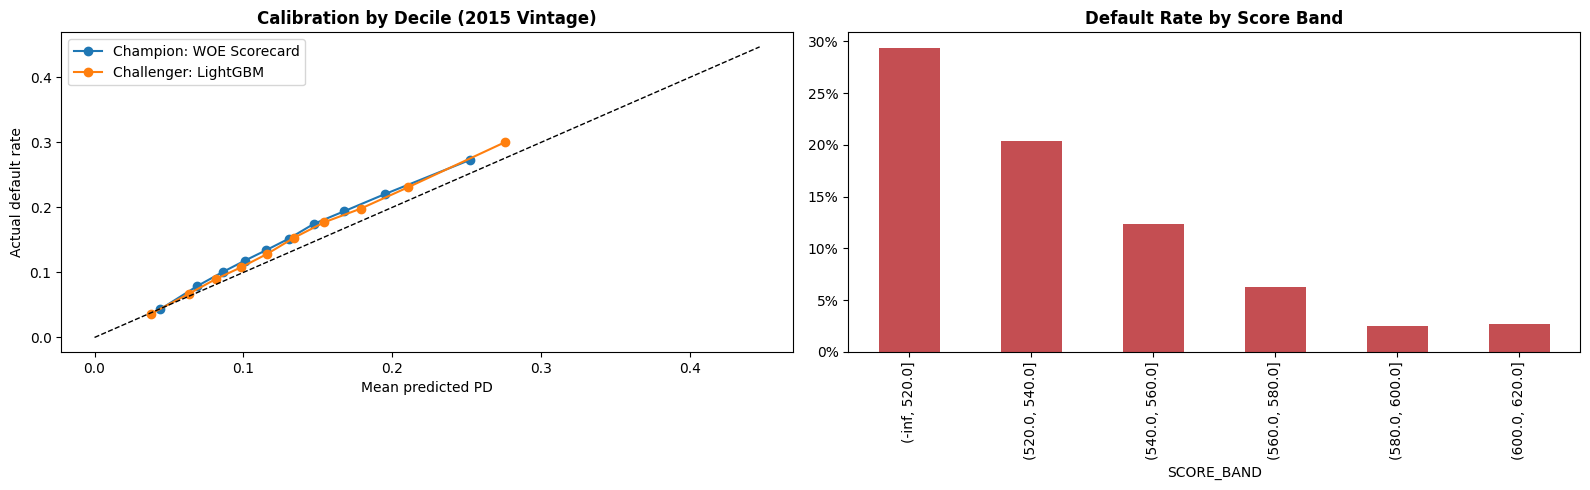

In [4]:
print("--- Calibration Check ---")

# 1. Calibration-in-the-large and Brier score
calib = pd.DataFrame({
    name: {'Mean Predicted PD': p.mean(), 'Actual Default Rate': y_test.mean(),
           'Predicted / Actual': p.mean() / y_test.mean(), 'Brier Score': brier_score_loss(y_test, p)}
    for name, p in {'Champion: WOE Scorecard': lr_preds, 'Challenger: LightGBM': lgb_preds}.items()}).T
display(calib.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 2. Calibration by decile
for name, p in {'Champion: WOE Scorecard': lr_preds, 'Challenger: LightGBM': lgb_preds}.items():
    decile = pd.qcut(pd.Series(p).rank(method='first'), 10, labels=False)
    cal = pd.DataFrame({'pred': p, 'actual': y_test, 'decile': decile}).groupby('decile').mean()
    axes[0].plot(cal['pred'], cal['actual'], marker='o', label=name)
top = max(y_test.mean() * 3, 0.4)
axes[0].plot([0, top], [0, top], 'k--', lw=1)
axes[0].set_xlabel('Mean predicted PD'); axes[0].set_ylabel('Actual default rate')
axes[0].set_title('Calibration by Decile (2015 Vintage)', fontweight='bold'); axes[0].legend()

# 3. Scorecard scaling (PDO = 20, 600 points = 50:1 odds)
PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
test['SCORE'] = offset + factor * np.log((1 - lr_preds) / lr_preds)
test['SCORE_BAND'] = pd.cut(test['SCORE'], bins=[-np.inf, 520, 540, 560, 580, 600, 620, np.inf])
bands = test.groupby('SCORE_BAND', observed=True).agg(Loans=('TARGET', 'size'), Default_Rate=('TARGET', 'mean'))
bands['Share of Loans'] = bands['Loans'] / len(test)
print("\n--- Default Rate by Credit Score Band (Champion Scorecard) ---")
display(bands.round(4))
bands['Default_Rate'].plot.bar(ax=axes[1], color='#C44E52')
axes[1].set_title('Default Rate by Score Band', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.tight_layout(); plt.show()

### Results

1. **Both models predict too few defaults.** The scorecard predicts a mean PD of **13.1%**, LightGBM **13.5%**, but **14.9%** of the 2015 loans defaulted. The ratios of predicted to actual are 0.88 and 0.91.
2. **The error is a shift in level, not in shape.** In the decile chart, both models run parallel to the 45° line and slightly above it, in every decile. The ranking is right, but the whole 2015 population defaults more. A bank would fix this by adjusting the model's intercept to the latest default rate, not by building a new model. LightGBM has a slightly better Brier score (0.1210 vs. 0.1227).
3. **The credit score works as intended.** The default rate falls steadily as the score rises:

| Score band | Share of loans | Default rate |
|---|---|---|
| ≤ 520 | 5.2% | 29.4% |
| 520–540 | 35.0% | 20.4% |
| 540–560 | 42.2% | 12.4% |
| 560–580 | 14.6% | 6.3% |
| 580–600 | 3.0% | 2.6% |
| 600–620 | 0.03% | 2.7% (only 75 loans) |

   The lowest band defaults 11 times more often than the best full band. Most borrowers score between 520 and 560 points, which means PDs of about 10–20%.

# Step 5: Population Stability (PSI and CSI)

**Why this step?** Step 4 showed that both models predict about 10% too few defaults for 2015. A model risk team asks why. There are two possible reasons:
* **the borrowers changed** (a different mix of applicants), which is called population drift; or
* **the same kind of borrower now defaults more often**, which is called concept drift.

The fix is different in each case, so we must know which one it is.

**How we do it.** The **Population Stability Index** compares the score distribution of the development loans (2010–2014) with that of the new loans (2015). We cut the development scores into 10 equal bins, and compare the share of development loans $E_i$ and of new loans $A_i$ in each bin:
$$PSI = \sum_{i=1}^{10} (A_i - E_i)\,\ln\!\left(\frac{A_i}{E_i}\right)$$

| PSI | Meaning | Usual action |
|---|---|---|
| < 0.10 | stable | none |
| 0.10 – 0.25 | moderate shift | investigate |
| > 0.25 | large shift | recalibrate or rebuild |

The **Characteristic Stability Index (CSI)** uses the same formula for each variable, through its WOE bins. If the score moves, CSI shows which variable caused it. We also compute the PSI of each issue year, which is how a bank monitors a model over time.

--- Population Stability Analysis ---


,PSI (2015 vs. 2010-2014),Assessment
Champion: WOE Scorecard,0.0002,Stable
Challenger: LightGBM,0.0038,Stable



--- Score PSI by Decile (Champion Scorecard) ---


,Expected %,Actual %,PSI Contribution
Bin 1,0.1,0.0980,0.0
Bin 2,0.1,0.0978,0.0
Bin 3,0.1,0.1021,0.0
Bin 4,0.1,0.1014,0.0
Bin 5,0.1,0.1006,0.0
Bin 6,0.1,0.1006,0.0
Bin 7,0.1,0.0993,0.0
Bin 8,0.1,0.0995,0.0
Bin 9,0.1,0.1006,0.0
Bin 10,0.1,0.1001,0.0



--- Characteristic Stability Index (Scorecard Variables) ---


,CSI,Assessment
mort_acc,1.0223,Significant shift
inq_last_6mths,0.0437,Stable
dti,0.0334,Stable
revol_util,0.0169,Stable
fico,0.0074,Stable
home_ownership,0.0042,Stable
log_annual_inc,0.0029,Stable
purpose,0.0010,Stable
LOAN_TO_INCOME,0.0007,Stable



--- Score PSI and Default Rate by Vintage (Champion Scorecard) ---


,Score PSI,Mean Predicted PD,Actual Default Rate
2010,0.1651,0.1078,0.1092
2011,0.2679,0.1014,0.1063
2012,0.0017,0.1297,0.1358
2013,0.0019,0.1310,0.1233
2014,0.0044,0.1345,0.1373
2015,0.0002,0.1308,0.1489


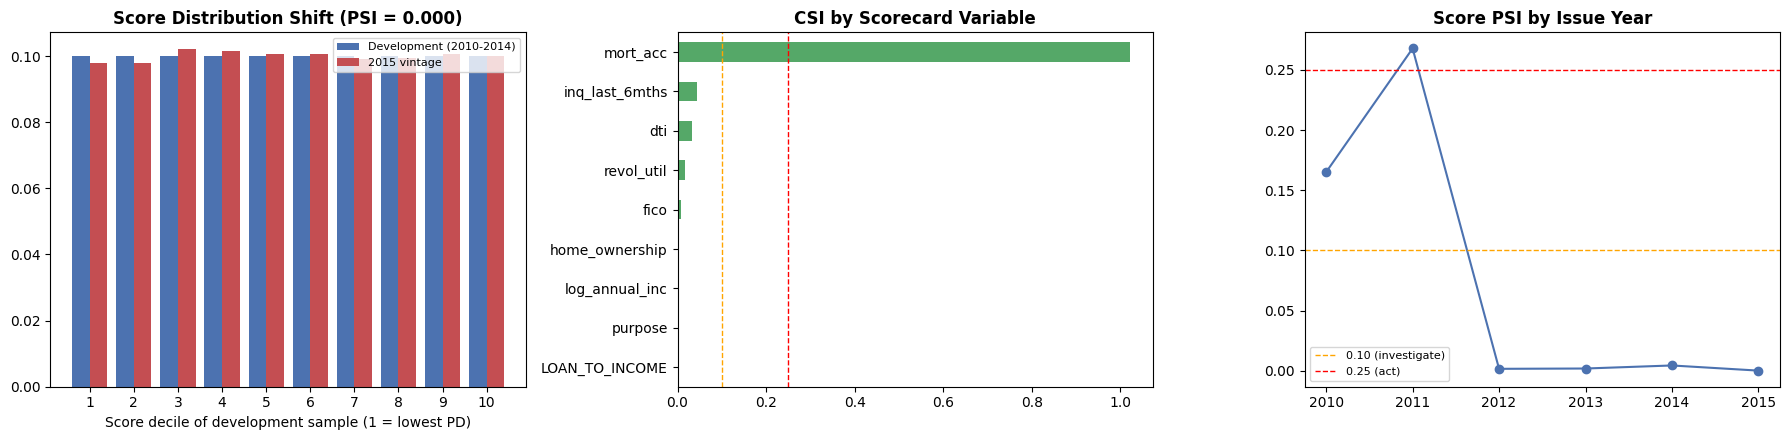

In [5]:
print("--- Population Stability Analysis ---")

def psi_table(expected, actual, n_bins=10, eps=1e-6):
    """PSI with bins defined on the expected (development) distribution."""
    edges = np.unique(np.quantile(expected, np.linspace(0, 1, n_bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    e = np.histogram(expected, edges)[0] / len(expected)
    a = np.histogram(actual, edges)[0] / len(actual)
    e_c, a_c = np.clip(e, eps, None), np.clip(a, eps, None)
    contrib = (a_c - e_c) * np.log(a_c / e_c)
    table = pd.DataFrame({'Expected %': e, 'Actual %': a, 'PSI Contribution': contrib},
                         index=[f'Bin {i + 1}' for i in range(len(e))])
    return contrib.sum(), table

def psi_discrete(expected, actual, eps=1e-6):
    """PSI for a discrete variable (e.g. WOE values = bins)."""
    e = pd.Series(np.round(expected, 6)).value_counts(normalize=True)
    a = pd.Series(np.round(actual, 6)).value_counts(normalize=True)
    idx = e.index.union(a.index)
    e, a = e.reindex(idx, fill_value=0).clip(lower=eps), a.reindex(idx, fill_value=0).clip(lower=eps)
    return float(((a - e) * np.log(a / e)).sum())

def psi_label(v):
    return 'Stable' if v < 0.10 else ('Moderate shift' if v < 0.25 else 'Significant shift')

# 1. Development (train) vs. 2015 scores for both models
lr_train_preds = lr.predict_proba(X_train_woe)[:, 1]
lgb_train_preds = lgb_model.predict_proba(X_train_lgb)[:, 1]
psi_lr, psi_lr_table = psi_table(lr_train_preds, lr_preds)
psi_lgb, psi_lgb_table = psi_table(lgb_train_preds, lgb_preds)
psi_summary = pd.DataFrame({'PSI (2015 vs. 2010-2014)': [psi_lr, psi_lgb],
                            'Assessment': [psi_label(psi_lr), psi_label(psi_lgb)]},
                           index=['Champion: WOE Scorecard', 'Challenger: LightGBM'])
display(psi_summary.round(4))
print("\n--- Score PSI by Decile (Champion Scorecard) ---")
display(psi_lr_table.round(4))

# 2. CSI: which scorecard variable has shifted?
csi = pd.DataFrame({'CSI': {col.replace('_woe', ''): psi_discrete(X_train_woe[col].values, X_test_woe[col].values)
                            for col in X_train_woe.columns}}).sort_values('CSI', ascending=False)
csi['Assessment'] = csi['CSI'].apply(psi_label)
print("\n--- Characteristic Stability Index (Scorecard Variables) ---")
display(csi.round(4))

# 3. PSI by issue year (each vintage vs. the full development sample)
all_woe = pd.concat([X_train_woe, X_test_woe], ignore_index=True)
all_years = np.concatenate([train['issue_year'].values, test['issue_year'].values])
all_lr = lr.predict_proba(all_woe)[:, 1]
by_year = pd.Series({yr: psi_table(lr_train_preds, all_lr[all_years == yr])[0] for yr in sorted(np.unique(all_years))},
                    name='Score PSI vs. development')
by_year.index.name = 'Issue Year'
default_by_year = pd.Series(np.concatenate([y_train, y_test])).groupby(all_years).mean()
print("\n--- Score PSI and Default Rate by Vintage (Champion Scorecard) ---")
display(pd.DataFrame({'Score PSI': by_year, 'Mean Predicted PD': pd.Series(all_lr).groupby(all_years).mean(),
                      'Actual Default Rate': default_by_year}).round(4))

# 4. Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
x = np.arange(len(psi_lr_table))
axes[0].bar(x - 0.2, psi_lr_table['Expected %'], 0.4, label='Development (2010-2014)', color='#4C72B0')
axes[0].bar(x + 0.2, psi_lr_table['Actual %'], 0.4, label='2015 vintage', color='#C44E52')
axes[0].set_xticks(x); axes[0].set_xticklabels(range(1, len(x) + 1))
axes[0].set_xlabel('Score decile of development sample (1 = lowest PD)')
axes[0].set_title(f'Score Distribution Shift (PSI = {psi_lr:.3f})', fontweight='bold'); axes[0].legend(fontsize=8)
csi['CSI'].sort_values().plot.barh(ax=axes[1], color='#55A868')
axes[1].axvline(0.10, color='orange', ls='--', lw=1); axes[1].axvline(0.25, color='red', ls='--', lw=1)
axes[1].set_title('CSI by Scorecard Variable', fontweight='bold')
axes[2].plot(by_year.index, by_year.values, marker='o', color='#4C72B0')
axes[2].axhline(0.10, color='orange', ls='--', lw=1, label='0.10 (investigate)')
axes[2].axhline(0.25, color='red', ls='--', lw=1, label='0.25 (act)')
axes[2].set_title('Score PSI by Issue Year', fontweight='bold'); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Results

1. **The score distribution did not change.** The PSI between 2010–2014 and 2015 is **0.0002** for the scorecard and **0.0038** for LightGBM, far below 0.10. Each development decile still holds 9.8–10.2% of the 2015 loans. The 2015 borrowers look exactly like the development borrowers.
2. **So the problem is concept drift.** The scorecard predicts 13.1% for 2015, about the same as for 2012–2014, but 14.9% of the 2015 loans defaulted. Borrowers with the same profile defaulted more often. The data does not explain why; possible reasons are credit factors we cannot see, loan terms or the wider credit market. The right response is to **recalibrate** the model to the latest default rate. PSI alone would not have found this, because it only watches the inputs. This is why banks always track PSI **together with** predicted vs. actual default rates.
3. **One variable is flagged: number of mortgage accounts (CSI = 1.02).** All other variables are stable (CSI ≤ 0.04). The most likely cause is missing data in the earliest loans: the training data then has a "missing" bin that is empty in 2015. With an empty bin, the log term in the formula becomes very large, and one empty bin that held about 7% of the training loans adds about 0.8 to the index. Two actions follow:
   * **Check the pattern** with `train.groupby('issue_year')['mort_acc'].apply(lambda s: s.isna().mean())`.
   * **Lesson for monitoring:** PSI and CSI react strongly to empty bins. Monitoring reports should merge small bins or show them separately.
4. **The early years are the outliers.** PSI is 0.17 for 2010 and 0.27 for 2011, but below 0.005 for 2012–2015. These are Lending Club's first and smallest years (23,000 loans in total), with a different credit policy and some different data fields. From 2012 on, the scored population is stable, while the actual default rate moves about ±1 point around the prediction each year. 2015 has the largest gap (+1.8 points).

# Step 6: Explainability (SHAP)

**Why this step?** Banks must understand and explain their models. Model risk rules require this (for example SR 11-7 in the US and OSFI Guideline E-23 in Canada). A lender must also be able to tell a customer why a loan was declined. A scorecard is easy to explain. For LightGBM we need a separate tool.

**How we do it.** SHAP (SHapley Additive exPlanations) splits each prediction into the contribution of each variable. A variable's SHAP value is its average extra effect over all possible orders in which the variables could be added:
$$\phi_j = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!\,(|F|-|S|-1)!}{|F|!}\Big[f(S \cup \{j\}) - f(S)\Big]$$
The average absolute SHAP value gives a ranking of variable importance, which we compare with the IV ranking from Step 2.

--- Generating SHAP Explanations (this may take a moment) ---

Top 10 Drivers of Default Risk (Global Interpretability):


,Feature,Mean Absolute SHAP
0,fico,0.305835
1,log_annual_inc,0.171761
2,inq_last_6mths,0.129228
3,LOAN_TO_INCOME,0.128955
4,dti,0.128109
5,open_acc,0.094169
6,REVOL_DEBT_TO_INCOME,0.093498
7,purpose_credit_card,0.076402
8,revol_util,0.065504
9,total_acc,0.058056


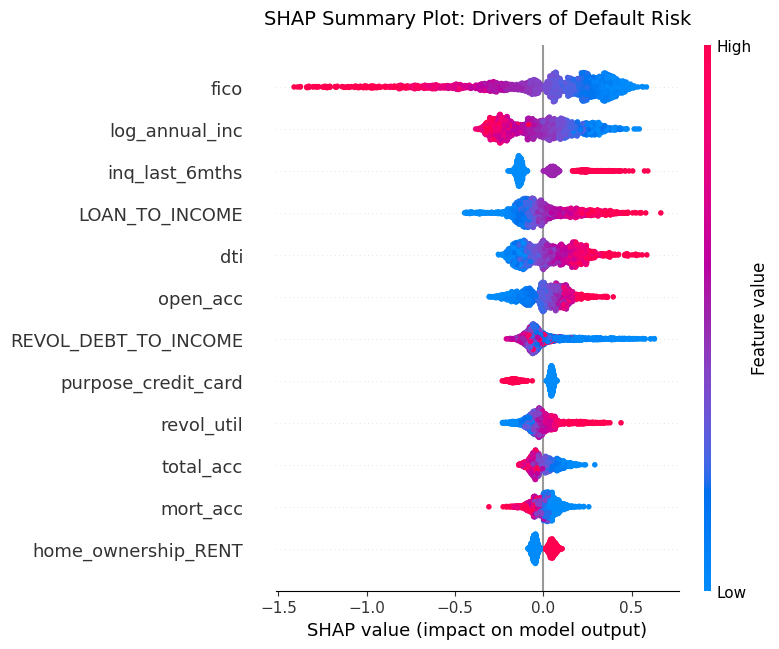

In [6]:
print("--- Generating SHAP Explanations (this may take a moment) ---")
explainer = shap.TreeExplainer(lgb_model)
X_test_sample = X_test_lgb.sample(min(2000, len(X_test_lgb)), random_state=42)
shap_values = explainer.shap_values(X_test_sample)
shap_vals_to_use = shap_values[1] if isinstance(shap_values, list) else shap_values

shap_df = pd.DataFrame({'Feature': X_test_sample.columns,
                        'Mean Absolute SHAP': np.abs(shap_vals_to_use).mean(axis=0)}).sort_values('Mean Absolute SHAP', ascending=False)
print("\nTop 10 Drivers of Default Risk (Global Interpretability):")
display(shap_df.head(10).reset_index(drop=True))

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_use, X_test_sample, show=False, max_display=12)
plt.title("SHAP Summary Plot: Drivers of Default Risk", fontsize=14, pad=15)
plt.show()

### Results

1. **The drivers agree with the scorecard.** The top SHAP variables are FICO, income, recent credit inquiries, loan-to-income and DTI, the same variables at the top of the IV ranking. LightGBM's advantage comes from using the same information better (finer cut-points and interactions), not from a hidden variable.
2. **The directions make sense.**
   * **Lower risk:** high FICO, high income, more mortgage accounts, and loans taken to refinance credit card debt.
   * **Higher risk:** many recent credit inquiries, a high loan-to-income ratio, high DTI, high card utilization, and renting a home.
3. **One pattern is not obvious.** Very **low** revolving-debt-to-income increases risk. Borrowers with almost no card debt often have a short credit history ("thin file"), which is a known risk group. A scorecard with only rising or falling bins would miss this U-shape. It is a good candidate for a separate bin in the next scorecard version.

# Step 7: Credit Decision and Financial Impact

**Why this step?** AUC and KS do not earn money. In the end, a PD model decides **which applicants to approve**. This step turns the model into a decision rule and measures its value in dollars.

**How we do it.** We value every 2015 test loan with its **real cash flows**:
* **Repaid loan:** earns the interest actually paid until payoff. With monthly rate $r$, instalment $A$, loan amount $L$ and $k$ monthly payments, the balance after $k$ payments is $B_k = L(1+r)^k - A\frac{(1+r)^k-1}{r}$, and the interest earned is $k\cdot A - (L - B_k)$. A prepaid loan earns less interest than a loan that runs to the end.
* **Defaulted loan:** earns interest until its last payment, then loses $EAD \times LGD$. EAD is the principal still owed, and LGD is the grade-level long-run average from Part 1 (about 91%).
* **Rejected loan:** zero profit.

**Decision rule:** approve a loan if its predicted PD ≤ cut-off. We test cut-offs from 1% to 80%, so the best cut-off is never forced by the edge of the grid.

**Check with a formula.** A loan is worth approving when its expected profit is positive: $(1-p)\,G - p\,C > 0$, where $G$ is the average profit of a good loan and $C$ the average net loss of a defaulted loan. This gives the **break-even PD**:
$$p^* = \frac{G}{G + C}$$

--- Simulating Portfolio Financial Impact (2015 Vintage, Realized Cash Flows) ---
Average profit per good loan:        $1,811
Average net loss per defaulted loan: $4,942
Break-even PD  p* = G / (G + C):      26.82%

Approve-all policy (Lending Club actual): $228.1M net profit on 283,026 loans (default rate 14.89%)

--- Optimal Operating Points ---


,Optimal Threshold,Approval Rate,Default Rate (Approved),Net Profit ($M),Gain vs. Approve-All ($M)
Model,,,,,
Champion: WOE Scorecard,0.36,0.9989,0.1486,228.1553,0.0561
Challenger: LightGBM,0.33,0.9904,0.1465,229.5883,1.4891



--- Champion: Threshold Scenarios Around the Optimum ---


,Threshold,Approval Rate,Approved Goods,Approved Defaults,Default Rate (Approved),Net Profit ($M)
32,0.33,0.9966,240266,41804,0.1482,227.9869
33,0.34,0.9979,240502,41922,0.1484,228.0597
34,0.35,0.9984,240605,41970,0.1485,228.0841
35,0.36,0.9989,240698,42011,0.1486,228.1553
36,0.37,0.9994,240796,42070,0.1487,228.1220
37,0.38,0.9996,240832,42088,0.1488,228.1347
38,0.39,0.9998,240853,42103,0.1488,228.1432


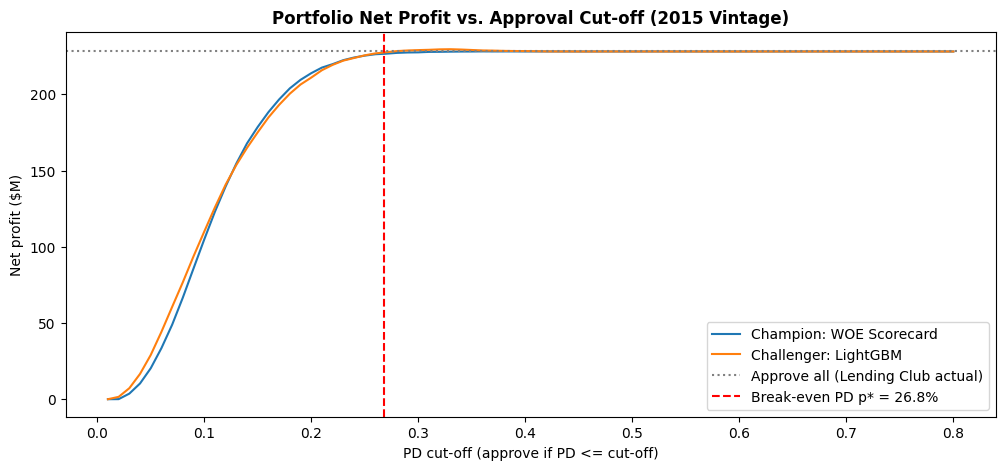

In [7]:
print("--- Simulating Portfolio Financial Impact (2015 Vintage, Realized Cash Flows) ---")

# 1. Realized cash flows of each test loan
r = test['int_rate'].values / 1200                                   # monthly interest rate
A = test['installment'].values
L = test['funded_amnt'].values
is_bad = test['TARGET'].values == 1
months_paid = np.where(is_bad, test['mob_exit'] - 4, test['mob_exit']).clip(0, 36).astype(float)
balance_k = L * (1 + r) ** months_paid - A * ((1 + r) ** months_paid - 1) / r
interest_earned = months_paid * A - (L - balance_k)

lgd = test['grade'].map(lgd_sat['lra_by_grade']).fillna(lgd_sat['lra_default_weighted']).values
credit_loss = np.where(is_bad, test['ead'].values * lgd, 0.0)
test['PROFIT'] = interest_earned - credit_loss

G = test.loc[~is_bad, 'PROFIT'].mean()          # average profit of a good loan
C = -test.loc[is_bad, 'PROFIT'].mean()          # average net cost of a defaulted loan
p_star = G / (G + C)
print(f"Average profit per good loan:        ${G:,.0f}")
print(f"Average net loss per defaulted loan: ${C:,.0f}")
print(f"Break-even PD  p* = G / (G + C):      {p_star:.2%}\n")

# 2. Grid search over cut-offs for both models
thresholds = np.round(np.arange(0.01, 0.801, 0.01), 2)
sims = {}
for name, p in {'Champion: WOE Scorecard': lr_preds, 'Challenger: LightGBM': lgb_preds}.items():
    rows = []
    for t in thresholds:
        approve = p <= t
        rows.append({'Threshold': t, 'Approval Rate': approve.mean(),
                     'Approved Goods': int((approve & ~is_bad).sum()), 'Approved Defaults': int((approve & is_bad).sum()),
                     'Default Rate (Approved)': is_bad[approve].mean() if approve.any() else np.nan,
                     'Net Profit ($M)': test.loc[approve, 'PROFIT'].sum() / 1e6})
    sims[name] = pd.DataFrame(rows)

# 3. Results vs. Lending Club's actual policy (approve everyone in the test sample)
approve_all = test['PROFIT'].sum() / 1e6
summary = []
for name, sim in sims.items():
    best = sim.loc[sim['Net Profit ($M)'].idxmax()]
    summary.append({'Model': name, 'Optimal Threshold': best['Threshold'], 'Approval Rate': best['Approval Rate'],
                    'Default Rate (Approved)': best['Default Rate (Approved)'], 'Net Profit ($M)': best['Net Profit ($M)'],
                    'Gain vs. Approve-All ($M)': best['Net Profit ($M)'] - approve_all})
summary_df = pd.DataFrame(summary).set_index('Model')
print(f"Approve-all policy (Lending Club actual): ${approve_all:,.1f}M net profit on {len(test):,} loans "
      f"(default rate {is_bad.mean():.2%})")
print("\n--- Optimal Operating Points ---")
display(summary_df.round(4))

champ = sims['Champion: WOE Scorecard']
opt = champ['Net Profit ($M)'].idxmax()
print("\n--- Champion: Threshold Scenarios Around the Optimum ---")
display(champ.iloc[max(0, opt - 3): opt + 4].round(4))

# 4. Profit curves
fig, ax = plt.subplots(figsize=(12, 5))
for name, sim in sims.items():
    ax.plot(sim['Threshold'], sim['Net Profit ($M)'], label=name)
ax.axhline(approve_all, color='grey', ls=':', label='Approve all (Lending Club actual)')
ax.axvline(p_star, color='red', ls='--', label=f'Break-even PD p* = {p_star:.1%}')
ax.set_xlabel('PD cut-off (approve if PD <= cut-off)'); ax.set_ylabel('Net profit ($M)')
ax.set_title('Portfolio Net Profit vs. Approval Cut-off (2015 Vintage)', fontweight='bold'); ax.legend()
plt.show()

### Results

1. **Break-even PD.** A good loan earned **\$1,811** of interest on average. A defaulted loan cost **\$4,942**, after the interest it paid before default. So the break-even PD is **p* = 26.8%**. A loan with a PD below 26.8% makes money on average.
2. **The profit curve is flat above p*.** Net profit rises steeply up to a cut-off of about 25%, and it is almost flat beyond 27%:

| Policy | Cut-off | Approval rate | Default rate (approved) | Net profit | Gain |
|---|---|---|---|---|---|
| Approve all (what Lending Club did) | – | 100% | 14.9% | \$228.1M | – |
| WOE scorecard | 36% | 99.9% | 14.9% | \$228.2M | +\$0.06M |
| LightGBM | 33% | 99.0% | 14.7% | \$229.6M | **+\$1.5M (+0.7%)** |

   Only about 1% of loans have a PD above p*, so the exact best cut-off (33% or 36%) is not meaningful. The clear result is that rejecting more loans below 27% PD loses money.
3. **Why the model adds so little here.** Lending Club had already rejected the high-risk applicants and set a higher interest rate for each riskier grade. Almost no approved borrower has a PD above the break-even level: risk-based pricing had already done the work of the cut-off. A PD model creates most of its value in three places:
   * **at application**, where the riskiest applicants appear. Our data has no rejected applications, so we cannot measure this;
   * **in pricing**, by setting a rate for each loan that covers its own risk;
   * **when costs are higher.** Funding and servicing costs would lower $G$, reduce p*, and make the cut-off matter much more.

# Summary of Part 3

We built a complete PD model on **612,745 Lending Club loans**: a WOE scorecard (champion) and LightGBM (challenger). They were trained on 2010–2014 loans, tested out of time on **283,026 loans from 2015** (14.9% default rate), and used to make profit-based lending decisions.

**Model performance (2015 test loans)**

| Model | ROC-AUC | Gini | KS | Predicted / actual PD | Brier | PSI |
| --- | --- | --- | --- | --- | --- | --- |
| Champion: WOE scorecard | 0.649 | 0.298 | 21.3 | 0.88 | 0.1227 | 0.0002 |
| Challenger: LightGBM | **0.672** | **0.344** | **25.0** | **0.91** | **0.1210** | 0.0038 |

**Credit decision**

| Policy | Cut-off | Approval rate | Default rate (approved) | Net profit (\$M) |
| --- | --- | --- | --- | --- |
| Approve all (Lending Club) | – | 100% | 14.9% | 228.1 |
| Champion scorecard | 36% | 99.9% | 14.9% | 228.2 |
| LightGBM challenger | 33% | 99.0% | 14.7% | 229.6 |

**Key findings**
1. **LightGBM ranks borrowers better** than the scorecard (+0.023 AUC, +3.7 KS). The scorecard remains the easier model to explain and to defend.
2. **The 2015 borrowers looked the same but defaulted more.** PSI is 0.0002, yet both models predict about 10% too few defaults. This is concept drift, and the fix is to recalibrate before using the PDs for pricing or expected loss.
3. **The break-even PD is 26.8%.** Because Lending Club had already screened and priced its loans, cutting deeper adds only \$1.5M (+0.7%).

**Good practice shown in this part**
* out-of-time validation;
* WOE bins learned on training data only;
* no class weights, so the PDs are real probabilities;
* explicit calibration, stability and explainability checks;
* profit based on each loan's own cash flows and the LGD from Part 1;
* no age, gender or location in the model.

**Limitations**
1. **Reject inference.** We only see approved loans. We cannot measure how the model would work on all applicants.
2. **Costs.** Funding and operating costs are not included. With them, the break-even PD would be lower and the model more valuable.
3. **Calibration drift.** The PDs should be recalibrated to the latest default rate before they are used for pricing or expected loss.

**Next:** Part 4 combines PD, LGD and EAD to project the portfolio loss in a recession.